In [8]:
import pandas as pd
df = pd.read_csv("../data/jobs.csv")
df.head()
df.info()
df.columns
df.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   applicationsCount  340 non-null    object 
 1   companyId          336 non-null    float64
 2   companyName        336 non-null    object 
 3   companyUrl         336 non-null    object 
 4   contractType       336 non-null    object 
 5   description        340 non-null    object 
 6   experienceLevel    340 non-null    object 
 7   jobUrl             340 non-null    object 
 8   location           340 non-null    object 
 9   postedTime         340 non-null    object 
 10  posterFullName     67 non-null     object 
 11  posterProfileUrl   67 non-null     object 
 12  publishedAt        303 non-null    object 
 13  salary             13 non-null     object 
 14  sector             332 non-null    object 
 15  title              340 non-null    object 
 16  workType           335 non

applicationsCount      0
companyId              4
companyName            4
companyUrl             4
contractType           4
description            0
experienceLevel        0
jobUrl                 0
location               0
postedTime             0
posterFullName       273
posterProfileUrl     273
publishedAt           37
salary               327
sector                 8
title                  0
workType               5
dtype: int64

In [9]:
df = df.dropna(subset=['companyName', 'sector', 'workType'])
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 331 entries, 0 to 339
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   applicationsCount  331 non-null    object 
 1   companyId          331 non-null    float64
 2   companyName        331 non-null    object 
 3   companyUrl         331 non-null    object 
 4   contractType       331 non-null    object 
 5   description        331 non-null    object 
 6   experienceLevel    331 non-null    object 
 7   jobUrl             331 non-null    object 
 8   location           331 non-null    object 
 9   postedTime         331 non-null    object 
 10  posterFullName     61 non-null     object 
 11  posterProfileUrl   61 non-null     object 
 12  publishedAt        296 non-null    object 
 13  salary             13 non-null     object 
 14  sector             331 non-null    object 
 15  title              331 non-null    object 
 16  workType           331 non-null

applicationsCount      0
companyId              0
companyName            0
companyUrl             0
contractType           0
description            0
experienceLevel        0
jobUrl                 0
location               0
postedTime             0
posterFullName       270
posterProfileUrl     270
publishedAt           35
salary               318
sector                 0
title                  0
workType               0
dtype: int64

In [10]:
df = df.drop_duplicates()
df.shape

(331, 17)

In [11]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [12]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    
    # convert to lowercase
    text = text.lower()
    
    # remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # split words
    words = text.split()
    
    # remove stopwords
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

In [13]:
df['cleaned_description'] = df['description'].apply(clean_text)
df[['description', 'cleaned_description']].head()

,description,cleaned_description
0,About the Team\n\nThe International Analytics ...,team international analytics team looking data...
1,"At Why Hiring, we believe in the power of conn...",hiring believe power connecting talented indiv...
2,Responsibilities/Accountabilities\n\n\n * Deve...,responsibilitiesaccountabilities develop advan...
3,* python and geospatial analytics experience ...,python geospatial analytics experience require...
4,About Us:\n\nLTIMindtree is a global technolog...,us ltimindtree global technology consulting di...


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 331 entries, 0 to 339
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   applicationsCount    331 non-null    object 
 1   companyId            331 non-null    float64
 2   companyName          331 non-null    object 
 3   companyUrl           331 non-null    object 
 4   contractType         331 non-null    object 
 5   description          331 non-null    object 
 6   experienceLevel      331 non-null    object 
 7   jobUrl               331 non-null    object 
 8   location             331 non-null    object 
 9   postedTime           331 non-null    object 
 10  posterFullName       61 non-null     object 
 11  posterProfileUrl     61 non-null     object 
 12  publishedAt          296 non-null    object 
 13  salary               13 non-null     object 
 14  sector               331 non-null    object 
 15  title                331 non-null    object 


In [15]:
skills = [
    'python',
    'sql',
    'aws',
    'azure',
    'machine learning',
    'deep learning',
    'tensorflow',
    'pytorch',
    'spark',
    'hadoop',
    'tableau',
    'power bi',
    'excel',
    'mongodb',
    'java',
    'c++',
    'data analysis',
    'nlp'
]

In [19]:
def extract_skills(text):
    found_skills = []
    for skill in skills:
        if skill in text:
            found_skills.append(skill)
    return found_skills
df['skills_found'] = df['cleaned_description'].apply(extract_skills)
df[['title','skills_found']].head(10)



,title,skills_found
0,"Data Science, Analytics, International","[python, sql, machine learning, excel]"
1,Junior Data Scientist,[excel]
2,Associate Data Scientist,"[python, sql, aws, azure, machine learning, te..."
3,Data Scientist,"[python, nlp]"
4,Data Scientist,"[python, sql, aws, machine learning, tensorflo..."
5,Machine Learning Engineer,"[python, machine learning, excel]"
6,Artificial Intelligence Engineer - Canada,"[python, sql, machine learning, deep learning,..."
7,Machine Learning Engineer (Canada),"[python, sql, aws, azure, machine learning, te..."
8,Machine Learning Engineer,"[python, machine learning, pytorch, spark]"
9,Data Scientist,"[python, machine learning, deep learning, tens..."


In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features = 2000,ngram_range=(1,2))
X = vectorizer.fit_transform(df['cleaned_description'])
y = df['experienceLevel']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train , y_test = train_test_split( 
    X,y,test_size=0.2,random_state=42
)
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)
predictions = model.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,predictions)
print("Accuracy",accuracy)


Accuracy 0.6268656716417911


In [31]:
from sklearn.metrics import classification_report
print(classification_report(y_test,predictions))
from sklearn.metrics import confusion_matrix
cm = (confusion_matrix(y_test,predictions))
print(cm)

                  precision    recall  f1-score   support

       Associate       0.00      0.00      0.00         2
     Entry level       0.71      0.65      0.68        31
Mid-Senior level       0.57      0.75      0.65        28
  Not Applicable       0.50      0.17      0.25         6

        accuracy                           0.63        67
       macro avg       0.45      0.39      0.39        67
    weighted avg       0.61      0.63      0.61        67

[[ 0  2  0  0]
 [ 0 20 11  0]
 [ 0  6 21  1]
 [ 0  0  5  1]]


c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

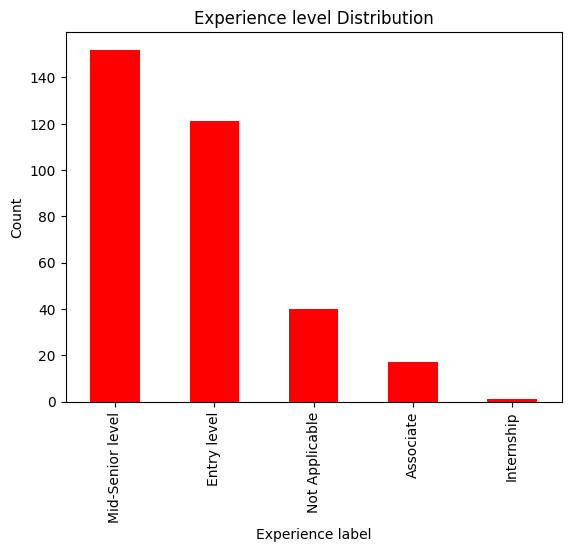

In [ ]:
import matplotlib.pyplot as plt
df['experienceLevel'].value_counts().plot(kind = 'bar',color = 'red')
plt.title("Experience level Distribution")
plt.xlabel("Experience label")
plt.ylabel("Count")
plt.show()

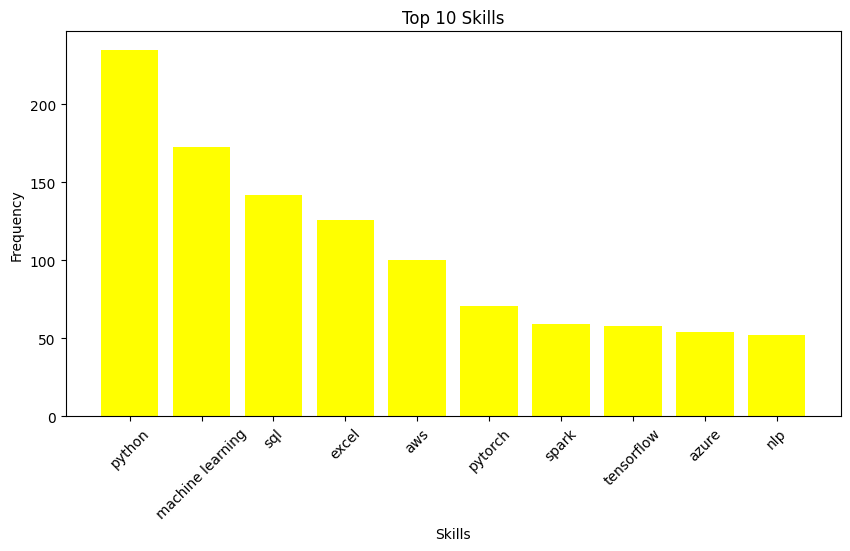

In [41]:
all_skills = []

for skills_list in df['skills_found']:
    all_skills.extend(skills_list)

from collections import Counter

skill_counts = Counter(all_skills)

top_skills = skill_counts.most_common(10)

skills = [item[0] for item in top_skills]
counts = [item[1] for item in top_skills]

plt.figure(figsize=(10,5))

plt.bar(skills, counts, color = "Yellow" )

plt.title("Top 10 Skills")
plt.xlabel("Skills")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

In [49]:
df.to_csv("../data/cleaned_jobs.csv", index=False)

In [50]:
import os

print(os.listdir("../data"))

['cleaned_jobs.csv', 'jobs.csv']
